# 01. Adult Census Income - 탐색적 데이터 분석(EDA)

- 작성: SKALA 광주 캠퍼스 4반 2조 / 박영서
- 목적: `src/` 모듈을 재사용해 원본 데이터를 살펴보고 전처리 전후를 비교한다.
- 주의: 검증이 끝난 함수는 노트북이 아니라 `src/` 모듈에 두고, 노트북은 탐색 용도로만 사용한다.

In [1]:
# 프로젝트 루트를 import 경로에 추가 (노트북은 notebooks/ 하위에서 실행됨)
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image

from src import clean, stats_analysis, viz

pd.set_option("display.max_columns", 50)

## 1. 데이터 로딩 — Pandas vs Polars

In [2]:
raw_path = clean.download_raw()  # 캐시가 있으면 재사용

pdf, t_pandas = clean.load_with_pandas(raw_path)
pldf, t_polars = clean.load_with_polars(raw_path)

clean.compare_loaders(pdf, pldf, t_pandas, t_polars)

2026-07-21 16:11:51,624 | INFO    | clean | 원본 캐시 사용: /Users/parkyoungseo/workspace/skala-gwangju-4class-team2/data/raw/adult.data (3881.2 KB)


2026-07-21 16:11:51,644 | INFO    | clean | Pandas 로딩 완료: shape=(32561, 15), 0.019초


2026-07-21 16:11:51,678 | INFO    | clean | Polars 로딩 완료: shape=(32561, 15), 0.034초


2026-07-21 16:11:51,685 | INFO    | clean | 로더 비교 | shape 일치=True, 결측 일치=True, Pandas 0.019s vs Polars 0.034s


{'pandas_shape': (32561, 15),
 'polars_shape': (32561, 15),
 'shape_equal': True,
 'pandas_nulls': 4262,
 'polars_nulls': 4262,
 'pandas_sec': 0.0193,
 'polars_sec': 0.0344,
 'speedup': 0.56,
 'nulls_equal': True}

In [3]:
pdf.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. 기본 EDA — 구조 · 결측치 · 타깃 분포

In [4]:
pdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
eda = clean.basic_eda(pdf)

print("결측치(건수, 비율%):", eda["null_counts"])
print("중복 행:", eda["n_duplicates"])
print("타깃 분포:", eda["target_dist"])
eda["describe"]

2026-07-21 16:11:51,716 | INFO    | clean | 기본 EDA | 32561행 15열, 중복 24행, 결측 컬럼 3개


결측치(건수, 비율%): {'workclass': (1836, 5.64), 'occupation': (1843, 5.66), 'native-country': (583, 1.79)}
중복 행: 24
타깃 분포: {'<=50K': 24720, '>50K': 7841}


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


## 3. 전처리 — 중복 제거 + 결측치 대체

In [6]:
df, history = clean.clean_data(pdf)

print("전처리 이력:", history)
print("전처리 후 결측치 합계:", int(df.isna().sum().sum()))
print("전처리 후 shape:", df.shape)

2026-07-21 16:11:51,741 | INFO    | clean | 전처리 완료 | 중복 24행 제거, 범주형 4261건·수치형 0건 대체, 최종 32537행


전처리 이력: {'dropped_duplicates': 24, 'filled_categorical': 4261, 'filled_numeric': 0}
전처리 후 결측치 합계: 0
전처리 후 shape: (32537, 15)


## 4. 시각화 — Seaborn 정적 차트 / Plotly 인터랙티브 차트

2026-07-21 16:11:52,041 | INFO    | viz | Seaborn 정적 차트 저장: /Users/parkyoungseo/workspace/skala-gwangju-4class-team2/outputs/figures/eda_seaborn.png


2026-07-21 16:11:52,233 | INFO    | viz | Plotly 인터랙티브 차트 저장: /Users/parkyoungseo/workspace/skala-gwangju-4class-team2/outputs/figures/eda_plotly.html


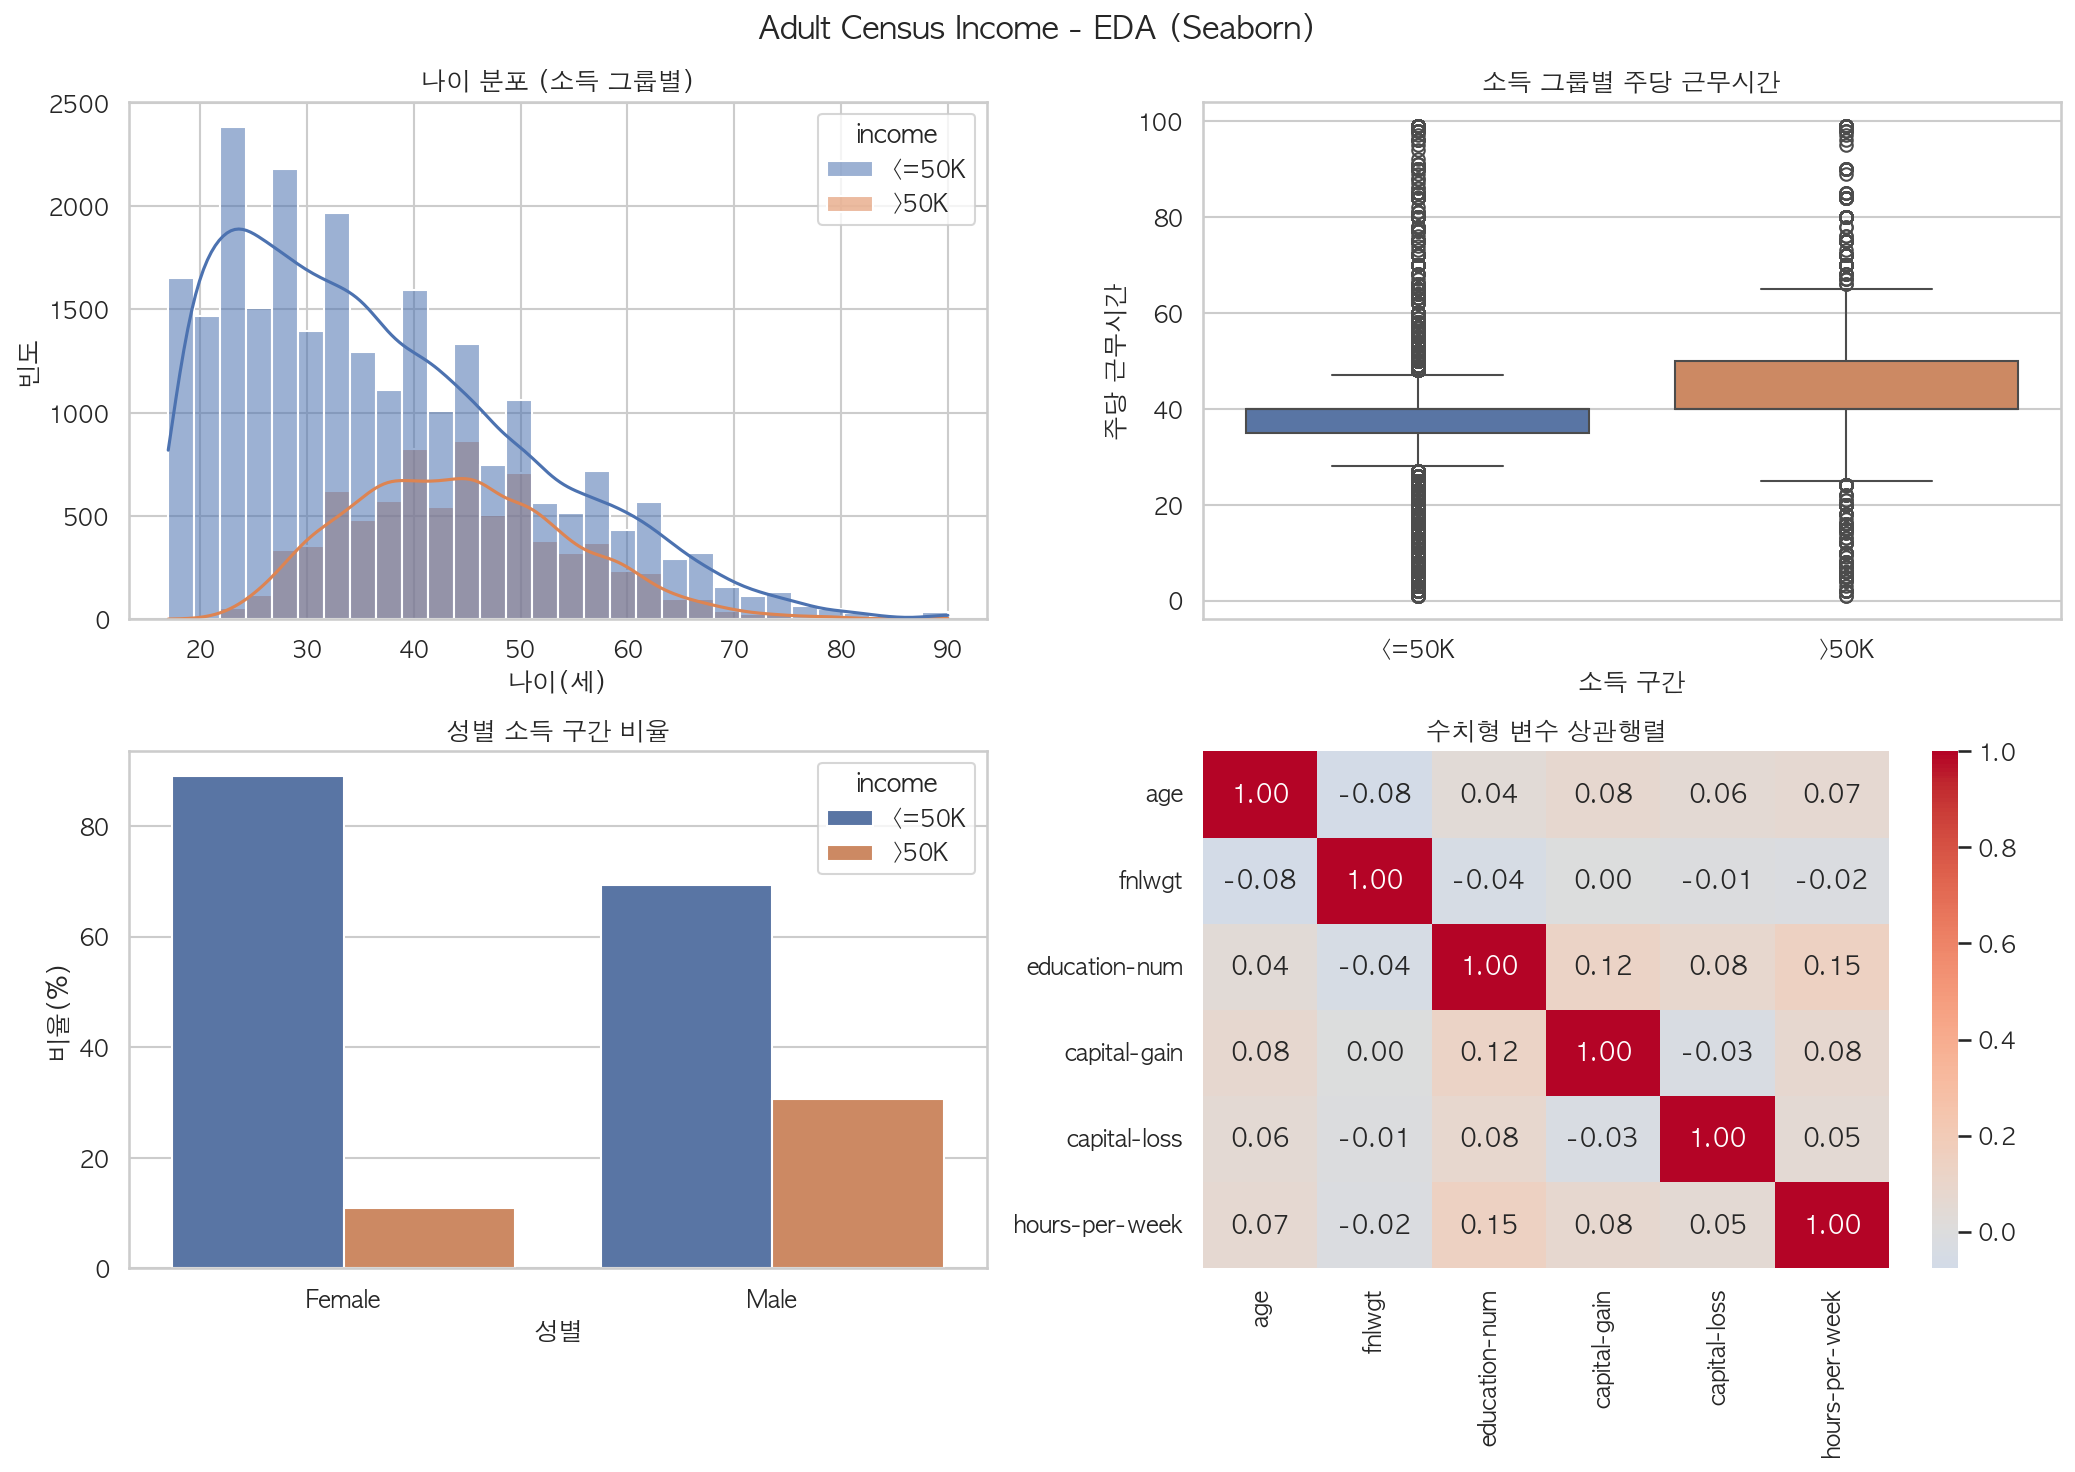

In [7]:
static_path = viz.plot_static_eda(df)
interactive_path = viz.plot_interactive(df)


Image(filename=str(static_path))

## 5. 통계 분석 — 기술통계 · 상관 · t-test · 카이제곱

In [8]:
display(stats_analysis.describe_numeric(df))

corr = stats_analysis.correlation_matrix(df)
display(corr)

print("상관 상위 5쌍:", stats_analysis.top_correlations(corr))

2026-07-21 16:11:52,241 | INFO    | stats | 기술통계 산출 완료: 6개 수치형 컬럼


,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.59,13.64,17.0,28.0,37.0,48.0,90.0
fnlwgt,32537.0,189780.85,105556.47,12285.0,117827.0,178356.0,236993.0,1484705.0
education-num,32537.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0
capital-gain,32537.0,1078.44,7387.96,0.0,0.0,0.0,0.0,99999.0
capital-loss,32537.0,87.37,403.10,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32537.0,40.44,12.35,1.0,40.0,40.0,45.0,99.0


2026-07-21 16:11:52,245 | INFO    | stats | 상관행렬 산출 완료: 6x6


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000,-0.076,0.036,0.078,0.058,0.069
fnlwgt,-0.076,1.000,-0.043,0.000,-0.010,-0.019
education-num,0.036,-0.043,1.000,0.123,0.080,0.148
capital-gain,0.078,0.000,0.123,1.000,-0.032,0.078
capital-loss,0.058,-0.010,0.080,-0.032,1.000,0.054
hours-per-week,0.069,-0.019,0.148,0.078,0.054,1.000


상관 상위 5쌍: [('education-num', 'hours-per-week', 0.148), ('education-num', 'capital-gain', 0.123), ('education-num', 'capital-loss', 0.08), ('age', 'capital-gain', 0.078), ('capital-gain', 'hours-per-week', 0.078)]


In [9]:
ttest = stats_analysis.run_ttest(df, value_col="hours-per-week")
chi2 = stats_analysis.run_chi2(df, col_a="sex", col_b="income")

print(ttest["interpretation"])
print(chi2["interpretation"])

2026-07-21 16:11:52,252 | INFO    | stats | t-test | hours-per-week: <=50K(38.84) vs >50K(45.47), t=-45.095, p=< 1e-308 < 0.05 → 귀무가설 기각. '<=50K' 그룹과 '>50K' 그룹의 hours-per-week 평균에 차이가 있다(통계적으로 유의).


2026-07-21 16:11:52,255 | INFO    | stats | chi2 | sex x income: chi2=1516.540, dof=1, p=< 1e-308 < 0.05 → 귀무가설 기각. 'sex'와(과) 'income'는 서로 연관이 있다(통계적으로 유의).


p=< 1e-308 < 0.05 → 귀무가설 기각. '<=50K' 그룹과 '>50K' 그룹의 hours-per-week 평균에 차이가 있다(통계적으로 유의).
p=< 1e-308 < 0.05 → 귀무가설 기각. 'sex'와(과) 'income'는 서로 연관이 있다(통계적으로 유의).


## 6. 다음 단계

모델 학습 · 저장 · 리포트 생성까지 포함한 전체 흐름은 아래 명령으로 한 번에 실행한다.

```bash
python -m src.run_pipeline
```